In [189]:
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [190]:
final_df = pd.read_csv("dataset/eeg_features.csv")

freq_bands = {
    "Delta": ["Delta"],
    "Theta": ["Theta"],
    "Alpha": ["Alpha"],
    "Beta": ["Beta"],
    "Gamma": ["Gamma"]
}

In [191]:
# classification between "0":"Alzheimer Disease Group" and "2": "Healthy Group"
A_C_df = final_df[final_df["Label"].isin([0, 2])]

In [192]:
X = A_C_df.drop(columns=["Label"])
y = A_C_df["Label"].values

# Replace Label=2 with 1 
y[y == 2] = 1

In [193]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_test_csp)

    accuracy = accuracy_score(y_test, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"A vs C: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_test, y_pred))



=== Processing Delta Band ===
Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 19 dim * 3.1e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
A vs C: CSP + LDA Accuracy (Delta Band): 0.5821
              precision    recall  f1-score   support

           0       0.60      0.77      0.67       850
           1       0.55      0.35      0.43       684

    accuracy                           0.58      1534
   macro avg       0.57      0.56      0.55      1534
weighted avg       0.57      0.58      0.56      1534


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 19 dim * 3.2e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projector

In [194]:
best_band = max(band_accuracies, key=band_accuracies.get)

print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.5821
Theta Band: 0.6701
Alpha Band: 0.7432
Beta Band: 0.7164
Gamma Band: 0.6701
The best EEG frequency band is Alpha, with an accuracy of 0.7432


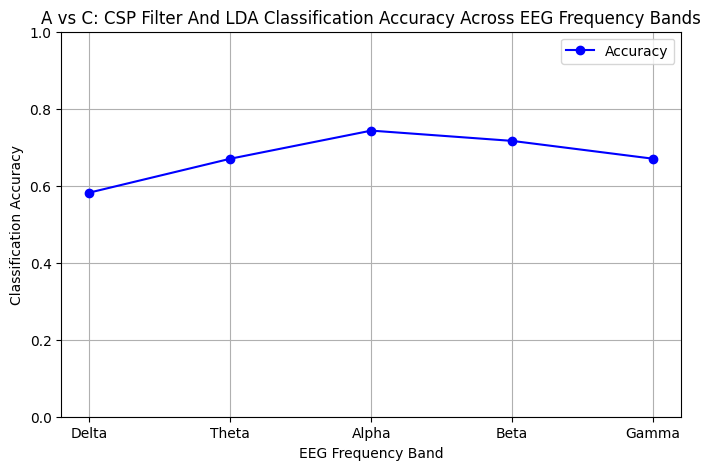

In [195]:
# Find the best frequency band
best_band = max(band_accuracies, key=band_accuracies.get)

# Plot classification accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("A vs C: CSP Filter And LDA Classification Accuracy Across EEG Frequency Bands")
plt.ylim(0, 1) 
plt.grid(True)
plt.legend()
plt.show()

In [196]:
# classification between "1":"Frontotemporal Dementia Group" and "2": "Healthy Group"
F_C_df = final_df[final_df["Label"].isin([1, 2])]

In [197]:
X = F_C_df.drop(columns=["Label"])
y = F_C_df["Label"].values

# Replace Label=1 with 0
y[y == 1] = 0

# Replace Label=2 with 1 
y[y == 2] = 1

In [198]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_test_csp)

    accuracy = accuracy_score(y_test, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"F vs C: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


=== Processing Delta Band ===
Computing rank from data with rank=None
    Using tolerance 1.1 (2.2e-16 eps * 19 dim * 2.6e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
F vs C: CSP + LDA Accuracy (Delta Band): 0.5790
              precision    recall  f1-score   support

           0       0.54      0.31      0.40       543
           1       0.59      0.79      0.68       685

    accuracy                           0.58      1228
   macro avg       0.57      0.55      0.54      1228
weighted avg       0.57      0.58      0.55      1228


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.9e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projector

In [199]:
# **Find the Best Frequency Band**
best_band = max(band_accuracies, key=band_accuracies.get)
print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.5790
Theta Band: 0.6319
Alpha Band: 0.7077
Beta Band: 0.7419
Gamma Band: 0.7533
The best EEG frequency band is Gamma, with an accuracy of 0.7533


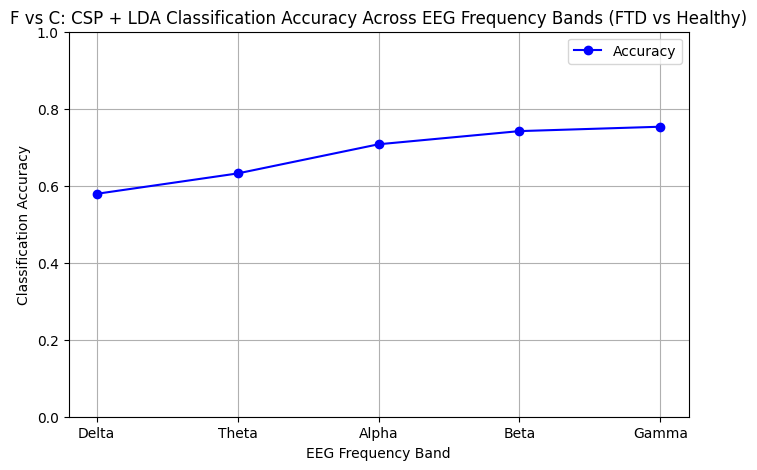

In [200]:
# **Plot Classification Accuracy Across Frequency Bands**
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("F vs C: CSP + LDA Classification Accuracy Across EEG Frequency Bands (FTD vs Healthy)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [201]:
# classification between "0":"Alzheimer Disease Group" and "1":"Frontotemporal Dementia Group"
A_F_df = final_df[final_df["Label"].isin([0, 1])]

In [202]:
X = A_F_df.drop(columns=["Label"])
y = A_F_df["Label"].values

In [203]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_test_csp)

    accuracy = accuracy_score(y_test, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"A vs F: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


=== Processing Delta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.7e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
A vs F: CSP + LDA Accuracy (Delta Band): 0.6375
              precision    recall  f1-score   support

           0       0.64      0.91      0.75       850
           1       0.60      0.21      0.31       543

    accuracy                           0.64      1393
   macro avg       0.62      0.56      0.53      1393
weighted avg       0.63      0.64      0.58      1393


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.8e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projector

In [204]:
# **Find the Best Frequency Band**
best_band = max(band_accuracies, key=band_accuracies.get)
print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.6375
Theta Band: 0.6159
Alpha Band: 0.6597
Beta Band: 0.6762
Gamma Band: 0.6935
The best EEG frequency band is Gamma, with an accuracy of 0.6935


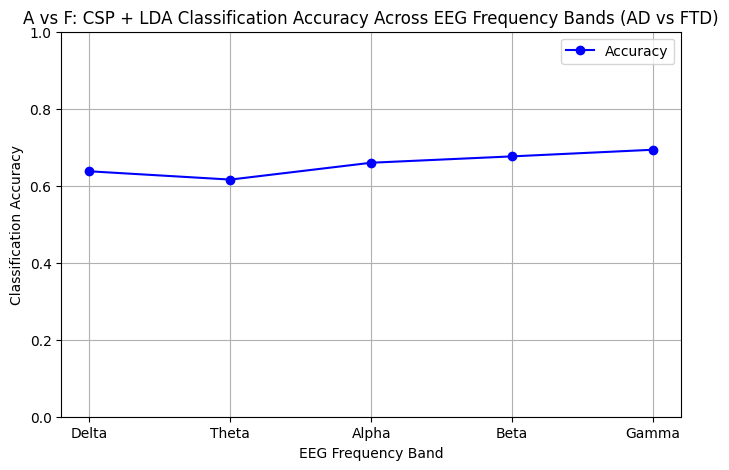

In [205]:
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("A vs F: CSP + LDA Classification Accuracy Across EEG Frequency Bands (AD vs FTD)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()